In [1]:
import numpy as np
import torch, torch.nn as nn
import gymnasium as gym

In [5]:
import sys
sys.path.insert(0, '..')
gym.register(id='Dragonsweeper-v0', entry_point="Environment:DragonSweeperEnv")
device = torch.device("cpu")

C:\Users\Milo\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment Dragonsweeper-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [6]:
env = gym.make("Dragonsweeper-v0", render_mode=None)

In [7]:
def flat_obs(obs, device=device):
    board = torch.tensor(obs['board'], dtype=torch.float32, device=device).flatten()
    player = torch.tensor(obs['player'], dtype=torch.float32, device=device).flatten()
    return torch.cat((board, player), dim=0)

In [8]:
obs_size = len(flat_obs(env.reset()[0])) # TODO: Remove this before end, yucky pointless reset
channel_size = 128
num_actions = env.action_space.n

In [9]:
embedding_size = 512 # 10 * 13 * 4 rounded down to nearest power of 2, approximately 4 dimensions to embed each cell into

In [17]:
simp_net = torch.nn.Sequential(
    nn.Linear(obs_size, embedding_size), # Embedding
    nn.LayerNorm(embedding_size),
    nn.ReLU(),
    nn.Linear(embedding_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, channel_size),
    nn.LayerNorm(channel_size),
    nn.ReLU(),
    nn.Linear(channel_size, num_actions), # Output logits
)
optimizer = torch.optim.Adam(params=simp_net.parameters())

In [11]:
# TODO: Clear up these names/comments and make the code a bit less terse, it's too much rn
def masked_probs(logits, board, info):
    temp_logits = logits.clone()
    
    # Zero unrevealds that aren't adjacent to revealds AND all unfilleds
    rempty = (board[:, :, 0] >= 0.5) & (board[:, :, 4] == 1)
    repad = rempty.float().unsqueeze(0).unsqueeze(0)
    near_cnt = nn.functional.conv2d(repad, torch.ones((1,1,3,3)), padding=1)[0,0] # Each position becomes number of enpty revealed in 3 by 3 (self inc)
    near = near_cnt > 0
    near_or_filled = near | ((board[:, :, 0] >= 0.5) & (board[:, :, 4] == 0)) # I'm having to do this separate check that it's revealed because the game zeros the empty helper when you're unrevealed, so counts it as filled!
    nnear_and_nfilled = ~near_or_filled.view(-1)
    temp_logits[:130][nnear_and_nfilled] = -float('inf')
    
    # Catch revealeds that were near revealeds, but which contain nothing
    # Of note: Being near a reveald includes just being a revealed, you're "near" yourself
    # So I catch those here
    temp_logits[:130][((board[:, :, 0] >= 0.5) & (board[:, :, 4] != 0)).view(-1)] = -float('inf')
    
    # Do a conditional check if required exp above current exp
    if info['xp'] < info['required xp']:
        temp_logits[130] = -float('inf')
        
    probs = torch.nn.functional.softmax(temp_logits, dim=0)
    return probs

In [16]:
losses = []
turn_cts = []

In [18]:
eps = 1e-6

In [14]:
# 1. If I know a move is non-sense, I should not let the player do it.
# 2. If the player wins, they should receive reward score and the episode should end.
    # env.unwrapped.game.score = score
    # terminated tells us that the player has either won or died
        # which is something
        # but (obviously) also separately need info on win or death

In [32]:
for episode in range(10000):
    obs, info = env.reset()

    actlps = []
    rewards = []
    turns = 0.
    
    done = False
    while not done:
        logits = simp_net(flat_obs(obs))
        probs = masked_probs(logits, torch.tensor(obs['board']), info)
        action = torch.multinomial(probs, num_samples=1).item()
        actlps.append(torch.log(probs[action]))

        next_obs, _, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        r = 0.
        if done:
            hp = info['hp']
            score = info['score']

            if hp == 0:
                r = float(score)
            else:
                r = float(score) + 1000. # Huge reward on win

        rewards.append(r)
        obs = next_obs
        turns += 1
    
    rs = []
    G = 0.
    for r in reversed(rewards):
        G = r + 0.9 * G
        rs.append(G)
    rs.reverse()
    rs = torch.tensor(rs)

    actlps = torch.stack(actlps)
    loss = -(actlps * rs).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    turn_cts.append(turns)
    
    if episode % 500 == 0:
        print(episode, loss, (episode / 100000)*100)

0 tensor(20.8458, grad_fn=<NegBackward0>) 0.0
500 tensor(0.0103, grad_fn=<NegBackward0>) 0.5
1000 tensor(-0., grad_fn=<NegBackward0>) 1.0
1500 tensor(5.7220e-06, grad_fn=<NegBackward0>) 1.5
2000 tensor(0.0012, grad_fn=<NegBackward0>) 2.0
2500 tensor(0.0432, grad_fn=<NegBackward0>) 2.5
3000 tensor(-0., grad_fn=<NegBackward0>) 3.0
3500 tensor(2.9296e-05, grad_fn=<NegBackward0>) 3.5000000000000004
4000 tensor(0.6518, grad_fn=<NegBackward0>) 4.0
4500 tensor(0.2273, grad_fn=<NegBackward0>) 4.5
5000 tensor(0.0006, grad_fn=<NegBackward0>) 5.0
5500 tensor(0.0007, grad_fn=<NegBackward0>) 5.5
6000 tensor(0.9445, grad_fn=<NegBackward0>) 6.0
6500 tensor(0.1476, grad_fn=<NegBackward0>) 6.5
7000 tensor(-0., grad_fn=<NegBackward0>) 7.000000000000001
7500 tensor(0.8118, grad_fn=<NegBackward0>) 7.5
8000 tensor(0.0423, grad_fn=<NegBackward0>) 8.0
8500 tensor(0.1885, grad_fn=<NegBackward0>) 8.5
9000 tensor(0.0268, grad_fn=<NegBackward0>) 9.0
9500 tensor(-0., grad_fn=<NegBackward0>) 9.5


6.061

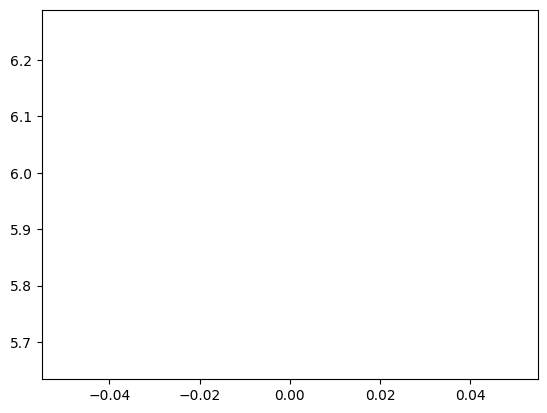

In [52]:
import matplotlib.pyplot as plt
plt.plot(sum(turn_cts[10999:])/len(turn_cts[10999:]))
plt
sum(turn_cts[20000:])/len(turn_cts[20000:])

tensor(5.2940e-22) tensor(8.3625e-14) tensor(1.0101e-12, grad_fn=<DivBackward0>)


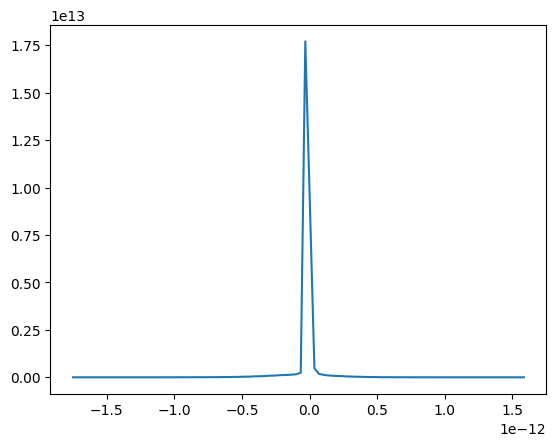

In [38]:
params = simp_net[3].weight
p_grad = params.grad
mean = p_grad.mean()
std = p_grad.std()
rat = std / params.std()
print(mean, std, rat)
hy, hx = torch.histogram(p_grad, density=True)
plt.plot(hx.detach()[:-1], hy.detach())
plt.show()

27.0

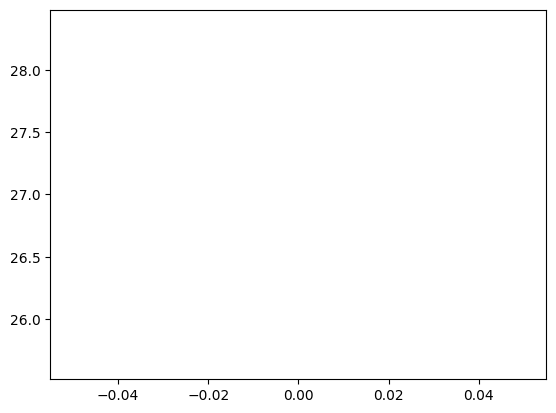

In [41]:
plt.plot(max(turn_cts))
max(turn_cts)